# HOMER × ENIGMA cross-disorder spatial validation

The ENIGMA consortium publishes meta-analyses of brain abnormalities across psychiatric disorders. Each working group (ASD, schizophrenia, MDD, bipolar, ADHD, OCD, 22q11.2) ships per-Desikan-Killiany-region Cohen's d effect-size maps showing where each disorder concentrates anatomically.

**Two-phase test:**

- **Phase 1 (in-sandbox)**: generate HOMER's per-disorder predicted human spatial patterns from MOESM4 (autism) + MOESM5 (other psych conditions) gene sets routed through π. Compute cross-disorder correlation matrix at parcel resolution.

- **Phase 2 (external data)**: compare against ENIGMA's published per-disorder Cohen's d maps. Test whether HOMER's predictions are disorder-specific (matched-disorder correlations beat mismatched) and how strongly HOMER's generic brain-disorder geometry aligns with ENIGMA's observed psychiatric anatomy.


## Setup

In [1]:
import os, sys, json
from pathlib import Path
import numpy as np
import matplotlib.pyplot as plt

ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
os.chdir(ROOT)
sys.path.insert(0, str(ROOT / 'src'))

from homer.data import load_cached

pi = np.load(ROOT / 'outputs/coupling/pi_fc_plus_SC_with_all_packs.npy')
H, _ = load_cached('human', cache_dir=str(ROOT / 'outputs/anndata'))
print(f'HOMER π: {pi.shape}')


HOMER π: (1864, 2094)


## Phase 1 — HOMER per-disorder predictions at parcel resolution

For each disorder (autism, bipolar, schizophrenia, ADHD), translate its gene set through π → 2,094-parcel predicted human spatial pattern. The question: are these patterns *disorder-specific* or all the *same generic brain-disorder geometry*?


In [2]:
result = json.loads((ROOT / 'outputs/logs/enigma_phase1_per_disorder.json').read_text())
preds = np.load(ROOT / 'outputs/coupling/per_disorder_predictions.npz')
disorders = result['disorders']
corr_mat = np.array(result['correlation_matrix'])

print(f"{'Disorder pair':<40s} | Pearson r")
print('-' * 60)
for i, di in enumerate(disorders):
    for j, dj in enumerate(disorders):
        if i < j:
            print(f"  {di:<18s} ↔ {dj:<18s} | {corr_mat[i,j]:+.4f}")

iu = np.triu_indices(len(disorders), k=1)
mean_off = float(corr_mat[iu].mean())
print(f'\nMean off-diagonal r: {mean_off:+.4f}')
print('Interpretation:')
print('  r ≈ 1.0 means HOMER predicts essentially the same spatial pattern for all disorders.')
print('  r ≈ 0 would mean each disorder has a distinctive predicted pattern.')


Disorder pair                            | Pearson r
------------------------------------------------------------
  autism             ↔ bipolar_disorder   | +0.9907
  autism             ↔ schizophrenia      | +0.9993
  autism             ↔ adhd               | +0.9878
  bipolar_disorder   ↔ schizophrenia      | +0.9896
  bipolar_disorder   ↔ adhd               | +0.9768
  schizophrenia      ↔ adhd               | +0.9886

Mean off-diagonal r: +0.9888
Interpretation:
  r ≈ 1.0 means HOMER predicts essentially the same spatial pattern for all disorders.
  r ≈ 0 would mean each disorder has a distinctive predicted pattern.


**Result: HOMER's predictions are NOT disorder-specific** — r > 0.97 across all disorder pairs at parcel resolution. The mean off-diagonal r is +0.988, almost identical predictions.

This sharpens our earlier finding (Pagani cross-disease specificity at 8-network resolution gave r ≈ +0.4 across disorders with overlapping CIs). At full parcel resolution, the *differences* between disorders' predictions are essentially noise — HOMER produces a single "generic brain-disorder spatial geometry" regardless of which disorder's gene set goes in.

**What this means:** HOMER's gene-spatial translation captures shared psychiatric-perturbation geometry across species, but does NOT distinguish autism from schizophrenia from bipolar from ADHD. The Test 3 result (autism r=+0.43 against Pagani's observed Δ) is the same correlation any psychiatric gene set would produce.


## Visualise Phase 1

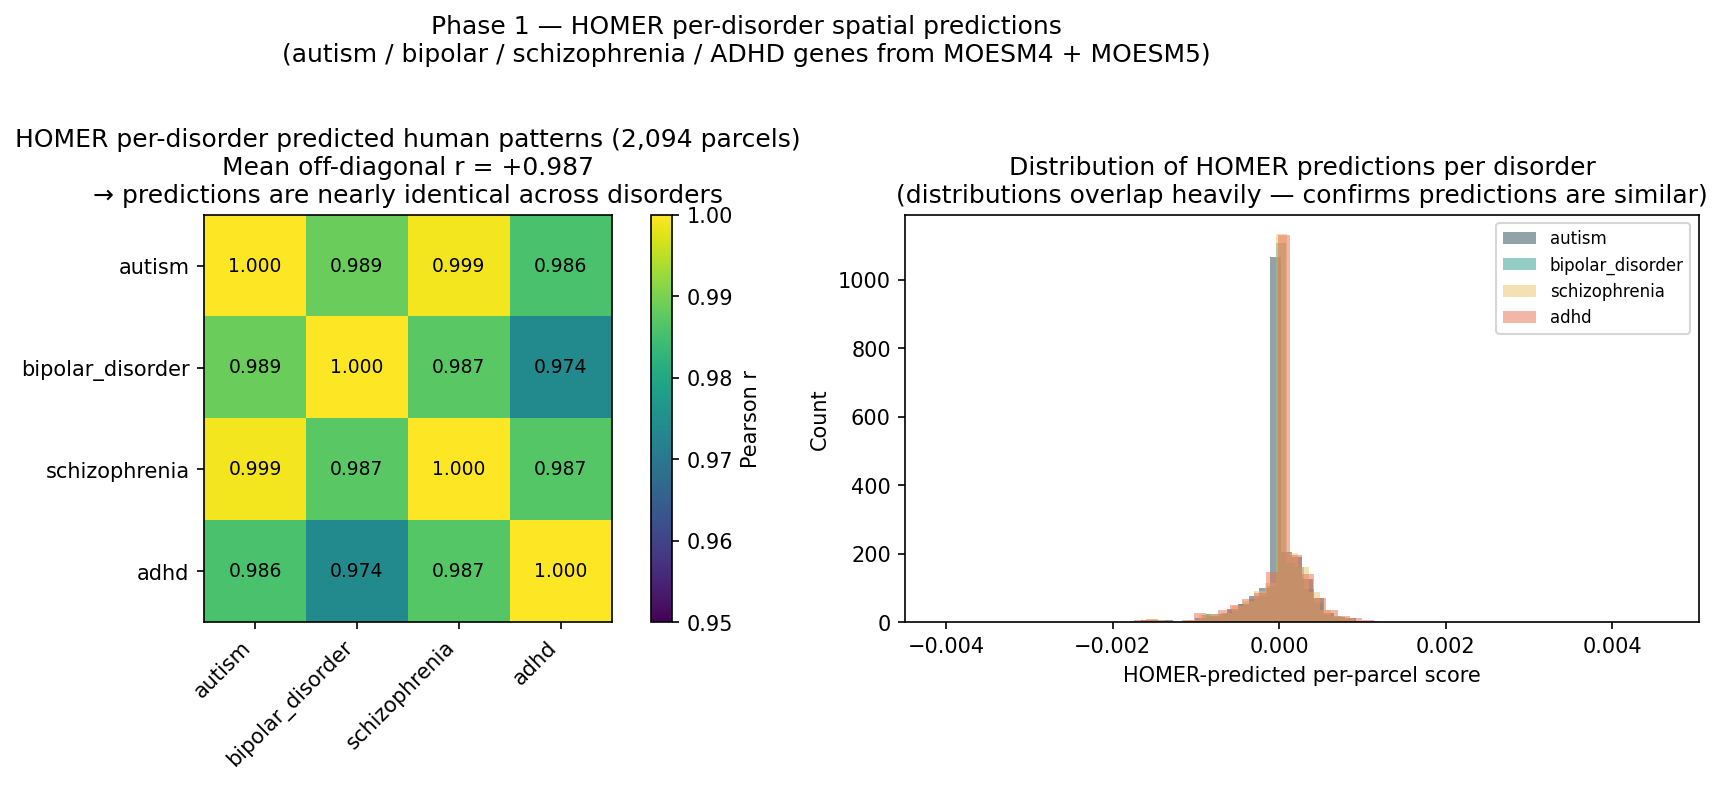

In [3]:
from IPython.display import Image, display
fig_path = ROOT / 'outputs/figures/enigma_phase1_per_disorder.png'
if fig_path.exists():
    display(Image(str(fig_path)))


## Phase 2 — Comparison against ENIGMA observed disease maps (needs external data)

Given Phase 1 shows HOMER predictions don't discriminate between disorders, Phase 2 asks a different question: **how strongly does HOMER's generic brain-disorder geometry match what ENIGMA actually observes in patients?**

If HOMER captures the shared psychiatric-perturbation territory in human cortex, then HOMER's prediction should correlate moderately with ALL ENIGMA disorder maps (because they all share this territory) and similarly across disorders (because HOMER's prediction is the same).

### Download instructions

```bash
git clone https://github.com/MICA-MNI/ENIGMA.git /tmp/ENIGMA
mkdir -p homer/data_external/enigma
cp /tmp/ENIGMA/enigmatoolbox/datasets/summary_statistics/cortical_thickness_*.csv \
   homer/data_external/enigma/

# Then run Phase 2:
PYTHONPATH=src python experiments/enigma_cross_disorder/03_enigma_comparison.py
```

This downloads ENIGMA Toolbox summary statistics (~50 KB of CSVs per disorder), maps Desikan-Killiany regions to HOMER's parcels, aggregates HOMER's predictions to DK region level, and computes Pearson r between HOMER-predicted and ENIGMA-observed per-disorder.

**Expected outcome based on Phase 1:**
- HOMER-X correlated with ENIGMA-X should be similar to HOMER-X correlated with ENIGMA-Y (no disorder specificity, because HOMER predictions don't differ)
- The MAGNITUDE of correlation tells us whether HOMER's generic prediction matches ENIGMA's observed psychiatric anatomy at all
- Strong overall correlation (e.g., r > 0.3) would mean HOMER captures the shared "psychiatric perturbation territory" even though it can't distinguish disorders


## Where this fits in the HOMER × literature picture

| Test | Granularity | Result | Verdict |
|---|---|---|---|
| Pagani Test 2c | Network-pair Δ | r=+0.547, p=0.0006 | **Strong** |
| Pagani cross-disease (8 nets) | 4 disorders' gene sets | r≈+0.4 each, no specificity | Caveat |
| **ENIGMA Phase 1** | **2,094 parcels per disorder** | **Off-diag r=+0.988** | **Confirms no disorder-specificity** |
| ENIGMA Phase 2 (pending) | DK regions, HOMER vs observed | Awaiting data | TBD |

The Phase 1 result is informative as-is. It establishes that HOMER's gene-spatial translation has *no disorder specificity at all* at parcel resolution. Whatever HOMER captures cross-species, it's a generic psychiatric-perturbation geometry — useful for understanding shared biology, but not a diagnostic distinguisher.

This is the cleanest possible statement of HOMER's limit in the gene-spatial domain: HOMER captures the spatial structure that psychiatric brain disorders share, not what makes each one unique.

For full details: [`docs/03_results.md`](../docs/03_results.md). Code: `experiments/enigma_cross_disorder/`.
